In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os, tqdm
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

from flax import nnx
import orbax.checkpoint as ocp

import jaxpm
from jaxpm.painting import cic_paint, cic_read
from jaxpm.kernels import fftk, invnabla_kernel
from jaxpm.nn import MLP
from jaxpm import camels, plotting, hpm, nn

jax.devices("gpu")

[cuda(id=0)]

In [3]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = [float(mesh_per_dim)] * 3

In [4]:
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0"
# SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_1"
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_2"

out_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=range(1, 33+4, 4),
    return_hydro=True,
)

cosmo = out_dict["cosmo"]
scales = out_dict["scales"]

dm_poss = out_dict["dm_poss"]
dm_vels = out_dict["dm_vels"]

gas_poss = out_dict["gas_poss"]
gas_vels = out_dict["gas_vels"]

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_2/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_2/snapshot_034.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_2/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_2/snapshot_050.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_2/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_2/snapshot_066.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_2/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_2/snapshot_082.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_2/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 9/9 [01:08<00:00,  7.60s/it]


In [5]:
# vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
# vcic_read = jax.vmap(cic_read, in_axes=(0,0))

# rho_dm = vcic_paint(jnp.zeros(mesh_shape), dm_poss, 1)
# rho_gas = vcic_paint(jnp.zeros(mesh_shape), gas_poss, cosmo.Omega_b / cosmo.Omega_c)
# rho_tot = rho_dm + rho_gas

# gas_rho_tot = vcic_read(rho_tot, gas_poss)

# kvec = fftk(mesh_shape)
# rho_k_tot = jax.vmap(jnp.fft.rfftn, in_axes=0)(rho_tot)
# gas_fscalar = vcic_read(
#     jax.vmap(jnp.fft.irfftn, in_axes=0)(rho_k_tot * invnabla_kernel(kvec)), 
#     gas_poss
# )

# gas_inputs = jnp.stack(
#     [
#         jnp.repeat(scales[:,jnp.newaxis], parts_per_dim**3, axis=1), 
#         jnp.log10(gas_rho_tot), 
#         jnp.arcsinh(gas_fscalar / 100)
#     ],
#     axis=-1,
# )

In [6]:
from jaxpm import data

X_particle, X_field, Y_particle, Y_field = data.get_offline_regression_data(
    out_dict,
    # x_labels=["rho", "fscalar", "vel_disp", "vel_div"],
    x_labels=["rho", "fscalar"],
    y_labels=["P"],
    standardize_input=False,
    include_scale=True,
)

gas_inputs = X_particle

In [7]:
gas_rho_tot = gas_inputs[...,1]
gas_fscalar = gas_inputs[...,2]

In [8]:
# for i in range(len(scales)):
#     plt.hist(gas_rho_tot[i])

In [9]:
# for i in range(len(scales)):
#     plt.hist(gas_fscalar[i])

# table

In [10]:
model = MLP(5, 1, 64, 4, nnx.Rngs(0))

# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/hpm_mlp_v5.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/hpm_mlp_cv1_v1.jx")
# checkpoint_file = "/cluster/home/athomsen/flatiron/repos/JaxPM/dev/hpm/nets/checkpoints/hpm_mlp_table.jx"
checkpoint_file = "/cluster/home/athomsen/flatiron/repos/JaxPM/dev/hpm/offline_regression/checkpoints/hpm_mlp_table_new.jx"
checkpointer = ocp.StandardCheckpointer()

abstract_model = nnx.eval_shape(lambda: model)
graphdef, abstract_params = nnx.split(abstract_model)

params = checkpointer.restore(checkpoint_file, abstract_params)
mlp_table = nnx.merge(graphdef, params)

/cluster/home/athomsen/flatiron/lib/python3.11/site-packages/orbax/checkpoint/_src/serialization/type_handlers.py:1386: UserWarning: Couldn't find sharding info under RestoreArgs. Populating sharding info from sharding file. Please note restoration time will be slightly increased due to reading from file instead of directly from RestoreArgs. Note also that this option is unsafe when restoring on a different topology than the checkpoint was saved with.
  warnings.warn(


# fit to sim

### particle-level

In [11]:
model = MLP(5, 1, 64, 4, nnx.Rngs(0))

# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/hpm_sim_v1.jx")
checkpoint_file = "/cluster/home/athomsen/flatiron/repos/JaxPM/dev/hpm/sims/checkpoints/hpm_mlp_sim_new.jx"
checkpointer = ocp.StandardCheckpointer()

abstract_model = nnx.eval_shape(lambda: model)
graphdef, abstract_params = nnx.split(abstract_model)

params = checkpointer.restore(checkpoint_file, abstract_params)
mlp_sim = nnx.merge(graphdef, params)

### pixel-level

In [12]:
# model = MLP(3, 1, 64, 4, nnx.Rngs(0))

# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/hpm_sim_field_cv0.jx")
# checkpointer = ocp.StandardCheckpointer()

# abstract_model = nnx.eval_shape(lambda: model)
# graphdef, abstract_params = nnx.split(abstract_model)

# params = checkpointer.restore(checkpoint_file, abstract_params)
# mlp_sim_pix = nnx.merge(graphdef, params)

# eval 

### MLP prediction (offline) vs. MLP prediction (online)

In [13]:
out_table = mlp_table(gas_inputs)[...,0]
out_sim = jnp.squeeze(mlp_sim(gas_inputs))

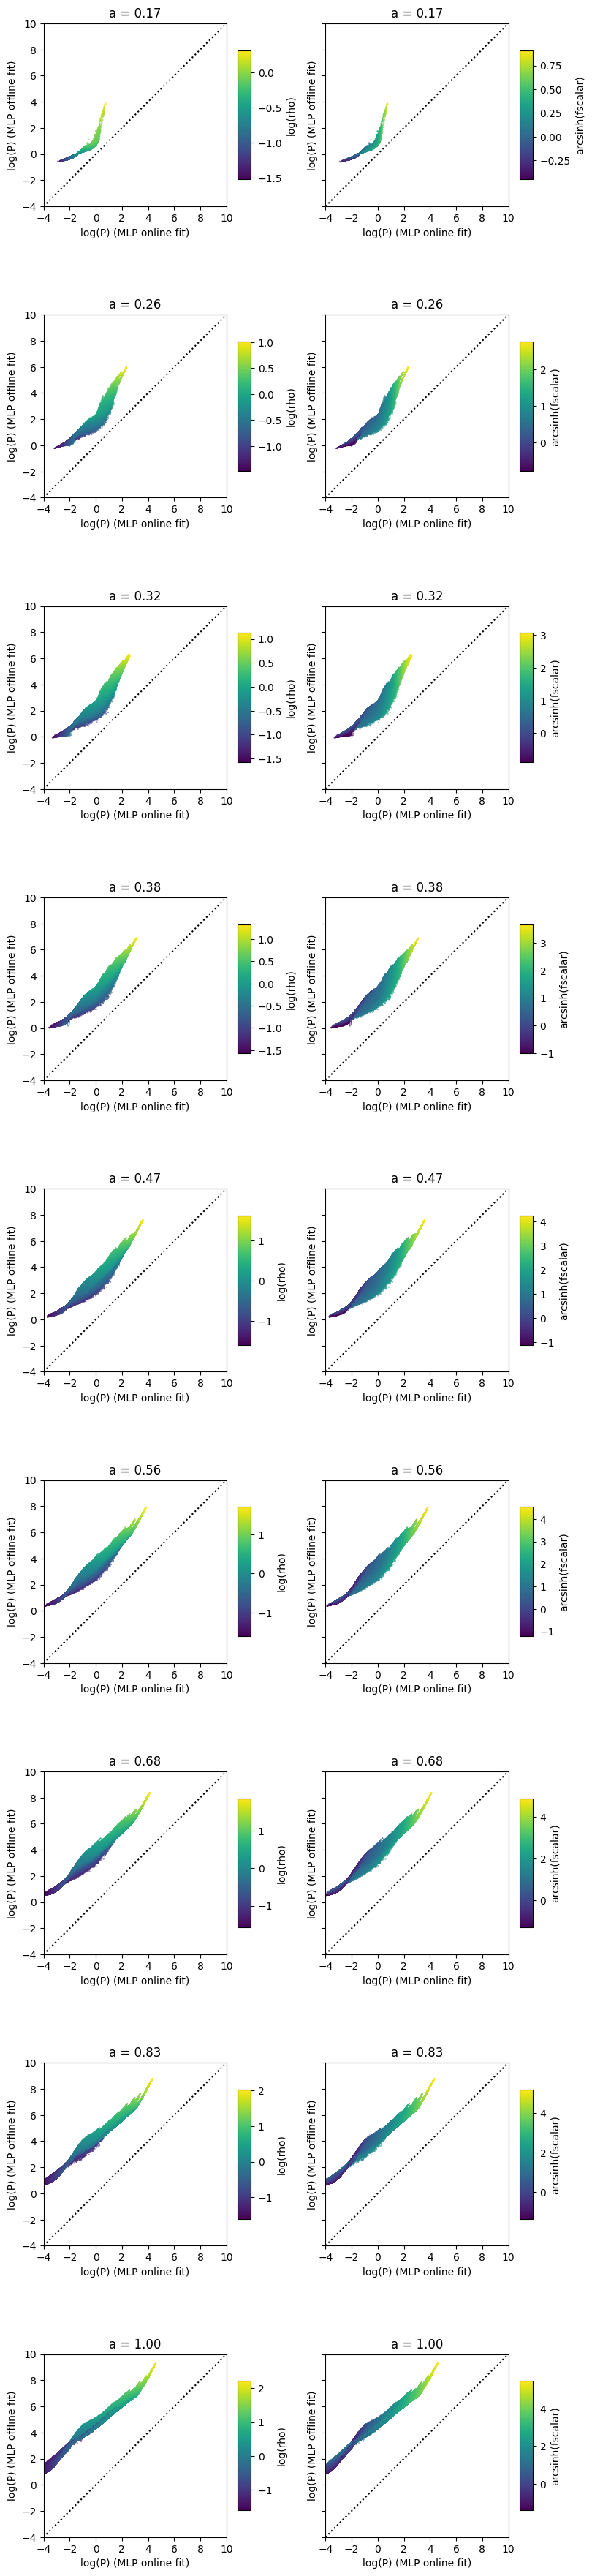

In [14]:
nrows = len(scales)

fig, ax = plt.subplots(figsize=(2*4, nrows*4), nrows=nrows, ncols=2, sharex="row", sharey="row")

# # Compute global limits for all subplots
# all_x = np.concatenate([out_table[i].flatten() for i in range(nrows)])
# all_y = np.concatenate([out_sim[i].flatten() for i in range(nrows)])

# xlim = ylim = (min(all_x.min(), all_y.min()), max(all_x.max(), all_y.max()))
# ticks = np.linspace(xlim[0], xlim[1], num=6)

xlim = (-4, 10)
ylim = xlim
ticks = np.linspace(-4, 10, num=8)

for i, scale in enumerate(scales):    
    # im = ax[i, 0].scatter(out_sim[i], out_table[i], s=0.1, c=np.log10(gas_rho_tot[i]))
    im = ax[i, 0].scatter(out_sim[i], out_table[i], s=0.1, c=gas_rho_tot[i])
    fig.colorbar(im, ax=ax[i, 0], orientation="vertical", shrink=0.5, aspect=10, label="log(rho)")

    # im = ax[i, 1].scatter(out_sim[i], out_table[i], s=0.1, c=np.arcsinh(gas_fscalar[i]))
    im = ax[i, 1].scatter(out_sim[i], out_table[i], s=0.1, c=gas_fscalar[i])
    fig.colorbar(im, ax=ax[i, 1], orientation="vertical", shrink=0.5, aspect=10, label="arcsinh(fscalar)")

    ax[i,0].plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], color="k", linestyle=":")
    ax[i,1].plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], color="k", linestyle=":")

    for j in range(2):
        ax[i, j].set(xlabel="log(P) (MLP online fit)", ylabel="log(P) (MLP offline fit)", title=f"a = {scale:.2f}")
        ax[i, j].set_xticks(ticks)
        ax[i, j].set_yticks(ticks)
        ax[i, j].set_xlim(xlim)
        ax[i, j].set_ylim(ylim)
        ax[i, j].set_aspect("equal")

fig.tight_layout()
plt.show()

### CAMELS truth vs. MLP prediction (online)

In [15]:
out_truth = jnp.squeeze(Y_particle)
out_sim = jnp.squeeze(mlp_sim(gas_inputs))

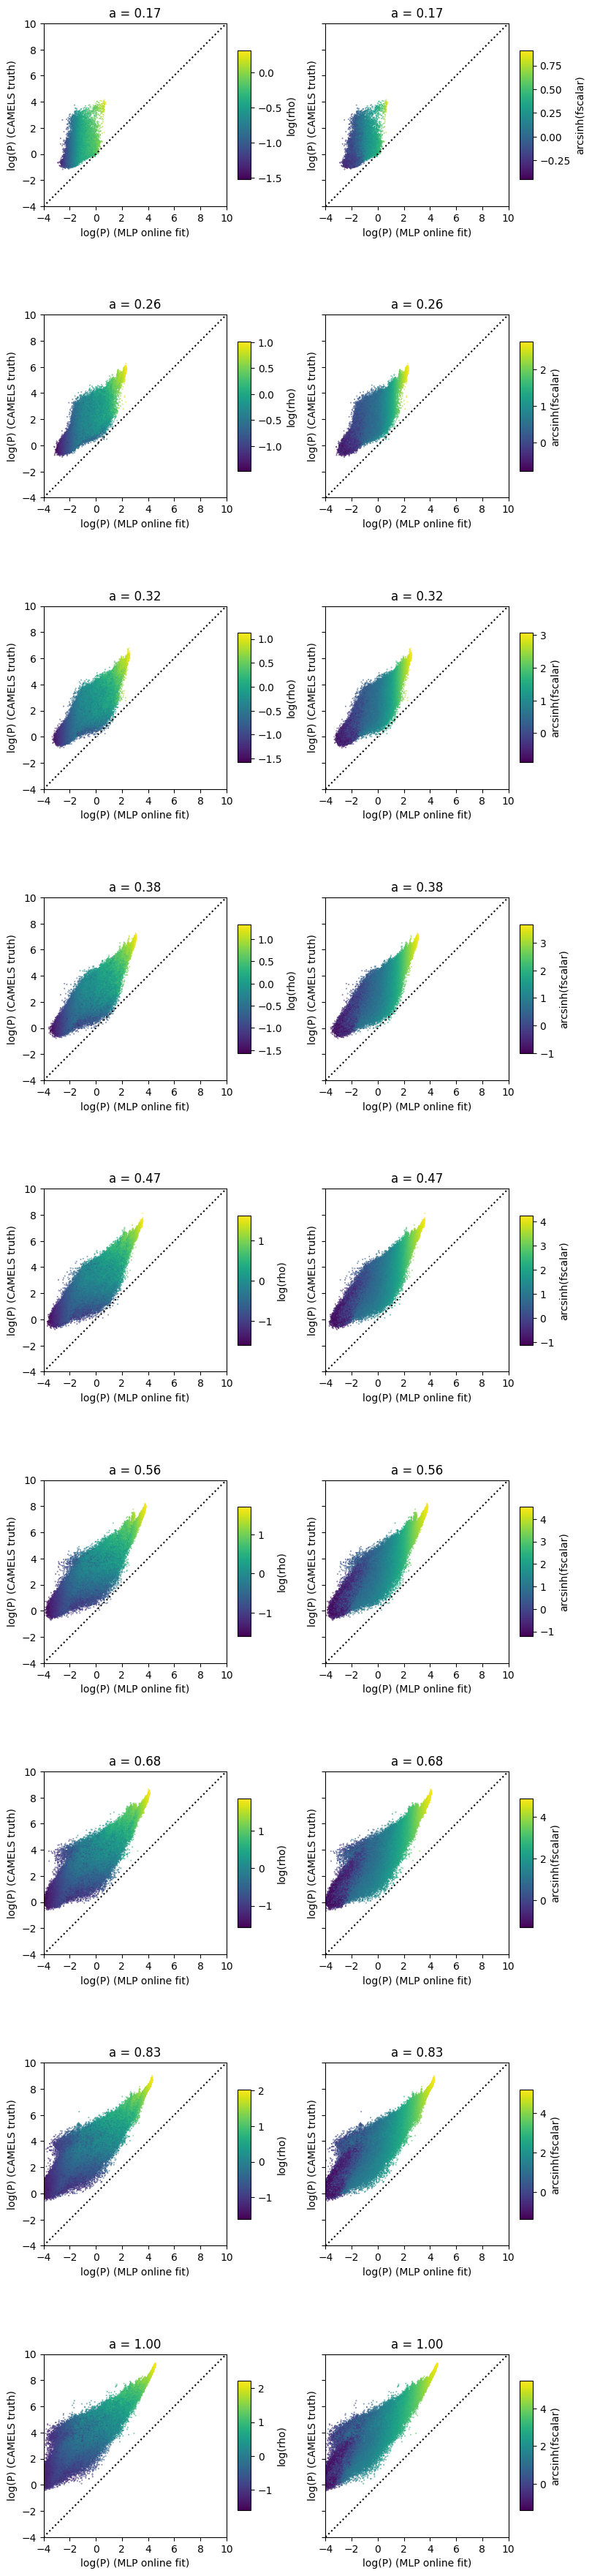

In [16]:
nrows = len(scales)

fig, ax = plt.subplots(figsize=(2*4, nrows*4), nrows=nrows, ncols=2, sharex="row", sharey="row")

# # Compute global limits for all subplots
# all_x = np.concatenate([out_table[i].flatten() for i in range(nrows)])
# all_y = np.concatenate([out_sim[i].flatten() for i in range(nrows)])

# xlim = ylim = (min(all_x.min(), all_y.min()), max(all_x.max(), all_y.max()))
# ticks = np.linspace(xlim[0], xlim[1], num=6)

xlim = (-4, 10)
ylim = xlim
ticks = np.linspace(-4, 10, num=8)

for i, scale in enumerate(scales):    
    im = ax[i, 0].scatter(out_sim[i], out_truth[i], s=0.1, c=gas_rho_tot[i])
    fig.colorbar(im, ax=ax[i, 0], orientation="vertical", shrink=0.5, aspect=10, label="log(rho)")

    im = ax[i, 1].scatter(out_sim[i], out_truth[i], s=0.1, c=gas_fscalar[i])
    fig.colorbar(im, ax=ax[i, 1], orientation="vertical", shrink=0.5, aspect=10, label="arcsinh(fscalar)")

    ax[i,0].plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], color="k", linestyle=":")
    ax[i,1].plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], color="k", linestyle=":")

    for j in range(2):
        ax[i, j].set(xlabel="log(P) (MLP online fit)", ylabel="log(P) (CAMELS truth)", title=f"a = {scale:.2f}")
        ax[i, j].set_xticks(ticks)
        ax[i, j].set_yticks(ticks)
        ax[i, j].set_xlim(xlim)
        ax[i, j].set_ylim(ylim)
        ax[i, j].set_aspect("equal")

fig.tight_layout()
plt.show()

### CAMELS truth vs. MLP prediction (offline)

In [17]:
out_table = mlp_table(gas_inputs)[...,0]
out_truth = jnp.squeeze(Y_particle)

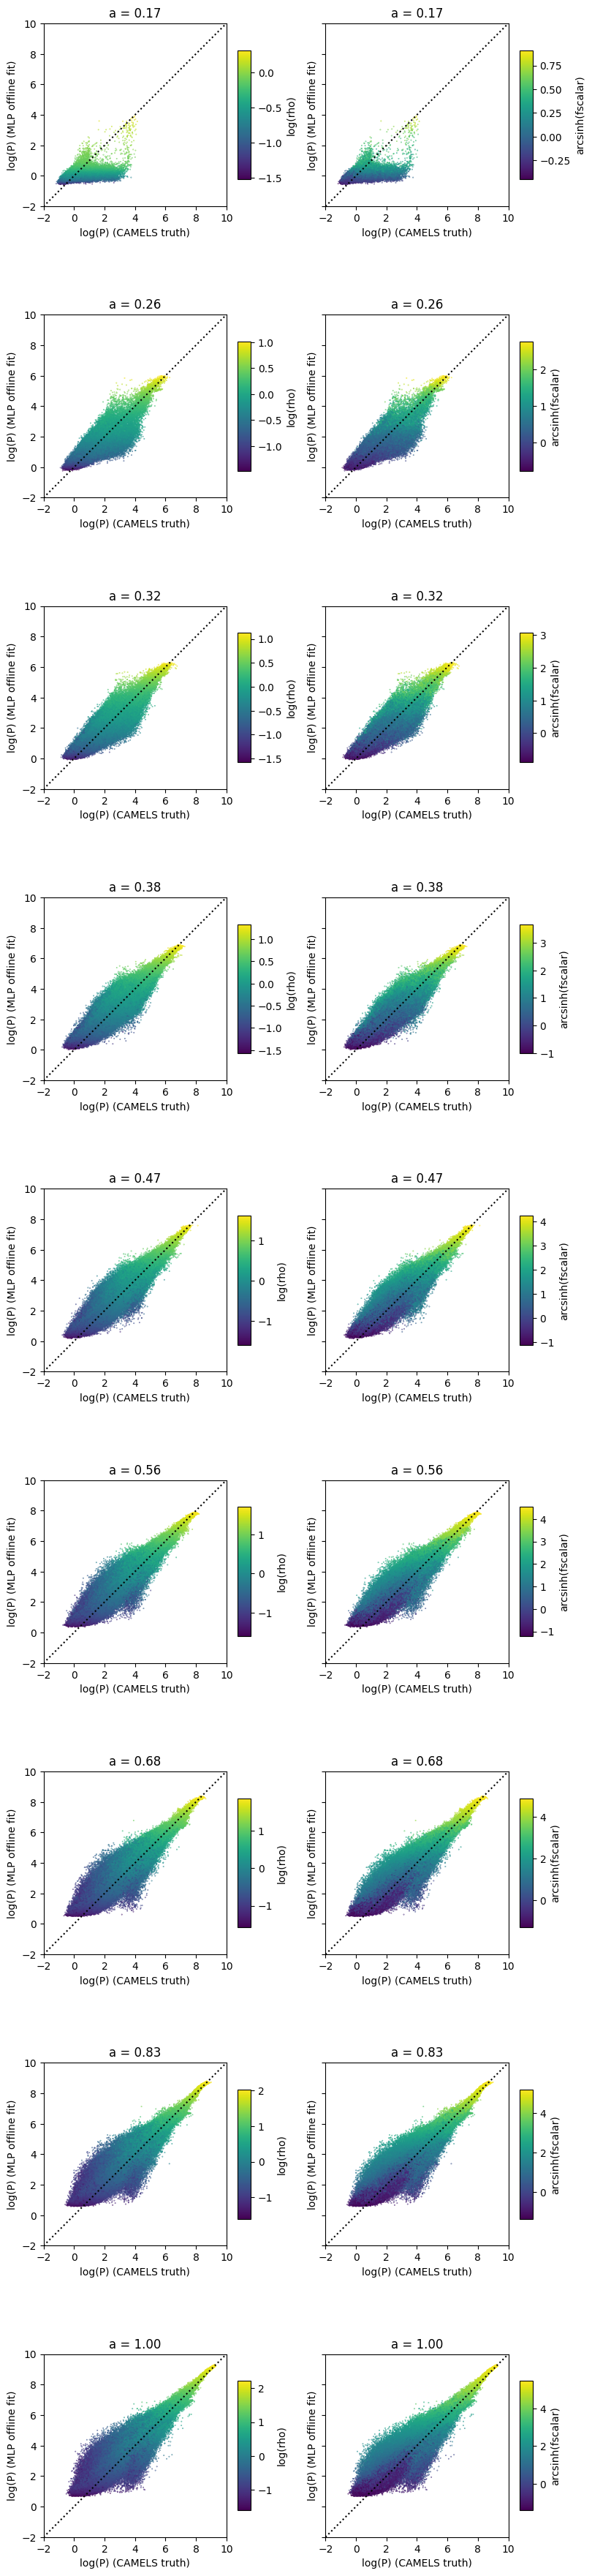

In [18]:
nrows = len(scales)

fig, ax = plt.subplots(figsize=(2*4, nrows*4), nrows=nrows, ncols=2, sharex="row", sharey="row")

xlim = (-2, 10)
ylim = xlim
ticks = np.linspace(-4, 10, num=8)

for i, scale in enumerate(scales):    
    im = ax[i, 0].scatter(out_truth[i], out_table[i], s=0.1, c=gas_rho_tot[i])
    fig.colorbar(im, ax=ax[i, 0], orientation="vertical", shrink=0.5, aspect=10, label="log(rho)")

    im = ax[i, 1].scatter(out_truth[i], out_table[i], s=0.1, c=gas_fscalar[i])
    fig.colorbar(im, ax=ax[i, 1], orientation="vertical", shrink=0.5, aspect=10, label="arcsinh(fscalar)")

    ax[i,0].plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], color="k", linestyle=":")
    ax[i,1].plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], color="k", linestyle=":")

    for j in range(2):
        ax[i, j].set(xlabel="log(P) (CAMELS truth)", ylabel="log(P) (MLP offline fit)", title=f"a = {scale:.2f}")
        ax[i, j].set_xticks(ticks)
        ax[i, j].set_yticks(ticks)
        ax[i, j].set_xlim(xlim)
        ax[i, j].set_ylim(ylim)
        ax[i, j].set_aspect("equal")

fig.tight_layout()
plt.show()

# correction by hand

In [71]:
# eps = 1e-8
# P = 10**out_table - eps 

# # P *= scales[:,jnp.newaxis]**5
# # P *= 1 / (1000 * scales[:,jnp.newaxis]**5)
# # P *= 1/1e4
# # P *= 1/(1e5 * scales[:,jnp.newaxis]**5)
# P *= 1/(1e4 * scales[:,jnp.newaxis]**5)
# out_table = jnp.log10(P + eps)

# OLD

In [36]:
jnp.log10((1-scales)/scales)

Array([ 0.6986166 ,  0.4485644 ,  0.33197308,  0.20443241,  0.06002945,
       -0.11116076, -0.33231303, -0.6775389 ,        -inf], dtype=float32)

In [17]:
(1+scales)/scales

Array([6.995934 , 4.809082 , 4.147697 , 3.6011517, 3.1482315, 2.7741752,
       2.4652507, 2.210117 , 2.       ], dtype=float32)

In [18]:
-2 * scales

Array([-0.3335594 , -0.5250609 , -0.6353851 , -0.76889026, -0.9309984 ,
       -1.1272844 , -1.3649542 , -1.6527328 , -2.        ], dtype=float32)

In [19]:
-2 - 3*jnp.log10(scales)

Array([ 0.33357048, -0.25753903, -0.50602126, -0.75450325, -1.0037569 ,
       -1.2530105 , -1.5022643 , -1.751518  , -2.        ], dtype=float32)

In [20]:
-6*jnp.loAAg10(1+scales)

AttributeError: module 'jax.numpy' has no attribute 'loAAg10'

In [ ]:
plt.plot(scales, -2*scales)

In [ ]:
plt.plot(scales, 3*jnp.log10(scales))

### "corrected"

In [ ]:
nrows = len(scales)

fig, ax = plt.subplots(figsize=(2*4, nrows*4), nrows=nrows, ncols=2, sharex="row", sharey="row")

# Compute global limits for all subplots
# all_x = np.concatenate([out_table[i,i_sub].flatten() for i in range(nrows)])
# all_y = np.concatenate([out_sim[i,i_sub].flatten() for i in range(nrows)])

# xlim = ylim = (min(all_x.min(), all_y.min()), max(all_x.max(), all_y.max()))
# ticks = np.linspace(xlim[0], xlim[1], num=6)

xlim = (-4, 10)
ylim = xlim
ticks = np.linspace(-4, 10, num=8)

for i, scale in enumerate(scales):
    # table_factor = scale
    # table_factor = 1/np.sqrt(scale)
    # table_factor = 100
    # factor = 0.1
    factor = 1
    # offset = scale/10
    # offset = 2.5
    offset = -2 * scale
    
    im = ax[i, 0].scatter(out_sim[i], out_table[i]*factor+offset, s=0.1, c=np.log10(gas_rho_tot[i]))
    fig.colorbar(im, ax=ax[i, 0], orientation="vertical", shrink=0.5, aspect=10, label="log(rho)")

    im = ax[i, 1].scatter(out_sim[i], out_table[i]*factor+offset, s=0.1, c=np.arcsinh(gas_fscalar[i]))
    fig.colorbar(im, ax=ax[i, 1], orientation="vertical", shrink=0.5, aspect=10, label="arcsinh(fscalar)")

    ax[i,0].plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], color="k", linestyle=":")
    ax[i,1].plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], color="k", linestyle=":")

    for j in range(2):
        ax[i, j].set(xlabel="log(P) (MLP direct fit)", ylabel="log(P) (MLP table)", title=f"a = {scale:.2f}")
        ax[i, j].set_xticks(ticks)
        ax[i, j].set_yticks(ticks)
        ax[i, j].set_xlim(xlim)
        ax[i, j].set_ylim(ylim)
        ax[i, j].set_aspect("equal")

fig.tight_layout()
plt.show()

In [ ]:
- 5 * jnp.log10(scales)

In [ ]:
out_table = mlp_table(gas_inputs)[...,0]
out_sim = jnp.squeeze(mlp_sim(gas_inputs))

nrows = len(scales)

fig, ax = plt.subplots(figsize=(2*4, nrows*4), nrows=nrows, ncols=2, sharex="row", sharey="row")

# Compute global limits for all subplots
all_x = np.concatenate([out_table[i].flatten() for i in range(nrows)])
all_y = np.concatenate([out_sim[i].flatten() for i in range(nrows)])

# xlim = ylim = (min(all_x.min(), all_y.min()), max(all_x.max(), all_y.max()))
# ticks = np.linspace(xlim[0], xlim[1], num=6)

xlim = (-4, 10)
ylim = xlim
ticks = np.linspace(-4, 10, num=8)

for i, scale in enumerate(scales):     
    im = ax[i, 0].scatter(out_sim[i], out_table[i]- 5*jnp.log10(scales[i]), s=0.1, c=np.log10(gas_rho_tot[i]))
    fig.colorbar(im, ax=ax[i, 0], orientation="vertical", shrink=0.5, aspect=10, label="log(rho)")

    im = ax[i, 1].scatter(out_sim[i], out_table[i] - 5*jnp.log10(scales[i]), s=0.1, c=np.arcsinh(gas_fscalar[i]))
    fig.colorbar(im, ax=ax[i, 1], orientation="vertical", shrink=0.5, aspect=10, label="arcsinh(fscalar)")

    ax[i,0].plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], color="k", linestyle=":")
    ax[i,1].plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], color="k", linestyle=":")

    for j in range(2):
        ax[i, j].set(xlabel="log(P) (MLP direct fit)", ylabel="log(P) (MLP table)", title=f"a = {scale:.2f}")
        ax[i, j].set_xticks(ticks)
        ax[i, j].set_yticks(ticks)
        ax[i, j].set_xlim(xlim)
        ax[i, j].set_ylim(ylim)
        ax[i, j].set_aspect("equal")

fig.tight_layout()
plt.show()

In [ ]:
jnp.log10(scales)

In [ ]:
n_sub = int(1e3)
i_sub = np.random.choice(np.arange(parts_per_dim**3), n_sub)
nrows = len(scales)

fig, ax = plt.subplots(figsize=(2*4, nrows*4), nrows=nrows, ncols=2, sharex="row", sharey="row")

# Compute global limits for all subplots
all_x = np.concatenate([out_table[i,i_sub].flatten() for i in range(nrows)])
all_y = np.concatenate([out_sim[i,i_sub].flatten() for i in range(nrows)])

# xlim = ylim = (min(all_x.min(), all_y.min()), max(all_x.max(), all_y.max()))
# ticks = np.linspace(xlim[0], xlim[1], num=6)

xlim = (-4, 10)
ylim = xlim
ticks = np.linspace(-4, 10, num=8)

for i, scale in enumerate(scales):
    # table_factor = scale
    # table_factor = 1/np.sqrt(scale)
    # table_factor = 100
    # factor = 0.1
    factor = 1
    # offset = scale/10
    # offset = 2.5
    offset = -2 * scale
    
    im = ax[i, 0].scatter(out_sim[i,i_sub], out_table[i,i_sub]*factor+offset, s=0.1, c=np.log10(gas_rho_tot[i,i_sub]))
    fig.colorbar(im, ax=ax[i, 0], orientation="vertical", shrink=0.5, aspect=10, label="log(rho)")

    im = ax[i, 1].scatter(out_sim[i,i_sub], out_table[i,i_sub]*factor+offset, s=0.1, c=np.arcsinh(gas_fscalar[i,i_sub]))
    fig.colorbar(im, ax=ax[i, 1], orientation="vertical", shrink=0.5, aspect=10, label="arcsinh(fscalar)")

    ax[i,0].plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], color="k", linestyle=":")
    ax[i,1].plot([xlim[0], xlim[1]], [ylim[0], ylim[1]], color="k", linestyle=":")

    for j in range(2):
        ax[i, j].set(xlabel="log(P) (MLP direct fit)", ylabel="log(P) (MLP table)", title=f"a = {scale:.2f}")
        ax[i, j].set_xticks(ticks)
        ax[i, j].set_yticks(ticks)
        ax[i, j].set_xlim(xlim)
        ax[i, j].set_ylim(ylim)
        ax[i, j].set_aspect("equal")

fig.tight_layout()
plt.show()

In [ ]:
nrows = len(scales)

fig, ax = plt.subplots(figsize=(2*4,nrows*4), nrows=nrows, ncols=2, sharex="row", sharey="row")

for i, scale in enumerate(scales):    
    im = ax[i,0].scatter(out_table[i], out_sim[i], s=0.1, c=np.log10(gas_rho_tot[i]))
    fig.colorbar(im, ax=ax[i,0], orientation="vertical", shrink=0.5, aspect=10, label="log(rho)")
                 
    im = ax[i,1].scatter(out_table[i], out_sim[i], s=0.1, c=np.arcsinh(gas_fscalar[i]))
    fig.colorbar(im, ax=ax[i,1], orientation="vertical", shrink=0.5, aspect=10, label="arcsinh(fscalar)")
    
    for j in range(2):
        ax[i,j].set(xlabel="log(P) (MLP table)", ylabel="log(P) (MLP direct fit)", title=f"a = {scale:.2f}")
        ax[i,j].set_aspect("equal")

fig.tight_layout()

### particle- vs. pixel-level loss

In [ ]:
# out_sim_part = jnp.squeeze(mlp_sim(gas_inputs))
# out_sim_pix = jnp.squeeze(mlp_sim_pix(gas_inputs))

In [ ]:
# nrows = len(scales)

# fig, ax = plt.subplots(figsize=(2*4,nrows*4), nrows=nrows, ncols=2, sharex="row", sharey="row")

# for i, scale in enumerate(scales):    
#     im = ax[i,0].scatter(out_sim_part[i], out_sim_pix[i], s=0.1, c=np.log10(gas_rho_tot[i]))
#     fig.colorbar(im, ax=ax[i,0], orientation="vertical", shrink=0.5, aspect=10, label="log(rho)")
                 
#     im = ax[i,1].scatter(out_sim_part[i], out_sim_pix[i], s=0.1, c=np.arcsinh(gas_fscalar[i]))
#     fig.colorbar(im, ax=ax[i,1], orientation="vertical", shrink=0.5, aspect=10, label="arcsinh(fscalar)")
    
#     for j in range(2):
#         ax[i,j].set(xlabel="log(P) (MLP sim particle)", ylabel="log(P) (MLP sim pixel)", title=f"a = {scale:.2f}")
#         ax[i,j].set_aspect("equal")

# fig.tight_layout()

In [ ]:
import jax.numpy as jnp

In [ ]:
A = jnp.arange(100)

In [ ]:
jnp.fft.rfft(A)

In [ ]:
jnp.fft.rfft(A + 10)

In [ ]:
from jaxpm.hpm import hpm_forces

i = -1
scale = scales[i]
dm_pos = dm_poss[i]
gas_pos = gas_poss[i]
gas_vel = gas_vels[i]
model = None

dm_force, gas_force, _ = hpm_forces(
    scale,
    dm_pos,
    gas_pos,
    gas_vel,
    mesh_shape,
    cosmo,
    model=None,
    gravity_only=True,
)

dm_force

In [ ]:
from jaxpm.hpm import hpm_forces

i = -1
scale = scales[i]
dm_pos = dm_poss[i]
gas_pos = gas_poss[i]
gas_vel = gas_vels[i]
model = None

dm_force, gas_force, _ = hpm_forces(
    scale,
    dm_pos,
    gas_pos,
    gas_vel,
    mesh_shape,
    cosmo,
    model=None,
    gravity_only=True,
)

dm_force